In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_fontja

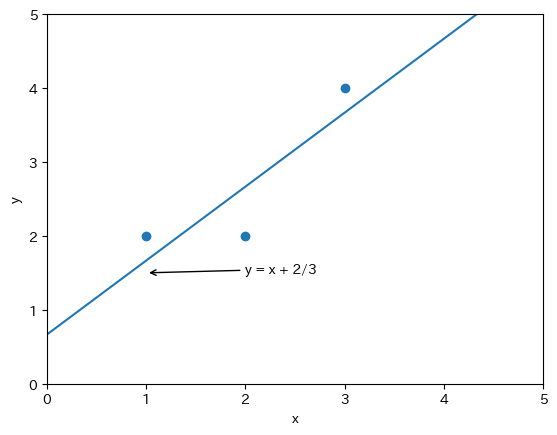

In [2]:
xx = np.linspace(0, 5, 100)
yy = xx + (2/3)
x = pd.Series([1,2,3], name = 'x')
y = pd.Series([2,2,4], name = 'y')
plt.scatter(x, y)
plt.plot(xx, yy)
plt.annotate('y = x + 2/3', xy=(1, 1.5), xytext=(2, 1.5), arrowprops=dict(arrowstyle='->')) 
plt.xlabel(x.name)
plt.ylabel(y.name)
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.savefig('../images/10_ols1.png')
plt.show()

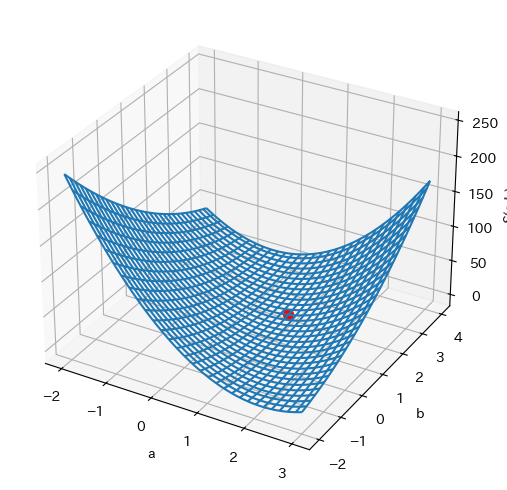

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# a,b の範囲
a = np.linspace(-2, 3, 120)
b = np.linspace(-2, 4, 120)
A, B = np.meshgrid(a, b)

# S(a,b)
S = (2-(A+B))**2 + (2-(2*A+B))**2 + (4-(3*A+B))**2

# 3D plot
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')

ax.plot_wireframe(A, B, S, rstride=4, cstride=4)

ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_zlabel("S(a,b)")
ax.scatter(1, 5/3, (2-(1+5/3))**2+(2-(2*1+5/3))**2+(4-(3*1+5/3))**2, color='red', s=50, label='Minimum Point')
fig.tight_layout()
plt.show()

In [8]:
import plotly.graph_objects as go

# Define the loss surface
a = np.linspace(-2, 3, 220)
b = np.linspace(-2, 4, 220)
A, B = np.meshgrid(a, b)
S = (2 - (A + B))**2 + (2 - (2*A + B))**2 + (4 - (3*A + B))**2

# Exact minimum for this OLS problem
a_min = 1.0
b_min = 2/3
s_min = (2 - (a_min + b_min))**2 + (2 - (2*a_min + b_min))**2 + (4 - (3*a_min + b_min))**2

fig = go.Figure()

# Surface with relatively dense contour lines (cross-sections)
fig.add_trace(
    go.Surface(
        x=A,
        y=B,
        z=S,
        colorscale="Viridis",
        opacity=0.92,
        showscale=True,
        contours={
            "x": {"show": True, "start": -2, "end": 3, "size": 0.25, "color": "white", "width": 1},
            "y": {"show": True, "start": -2, "end": 4, "size": 0.25, "color": "white", "width": 1},
            "z": {"show": True, "start": float(np.min(S)), "end": float(np.max(S)), "size": 8, "color": "white", "width": 1},
        },
        hovertemplate="a=%{x:.2f}<br>b=%{y:.2f}<br>S(a,b)=%{z:.2f}<extra></extra>",
        name="S(a,b)"
    )
)

# Minimum point on the surface
fig.add_trace(
    go.Scatter3d(
        x=[a_min],
        y=[b_min],
        z=[s_min],
        mode="markers+text",
        marker=dict(size=7, color="red"),
        text=[f" minimum<br>(a, b)=({a_min:.2f}, {b_min:.2f})"],
        textposition="top center",
        name="minimum",
        hovertemplate="minimum<br>a=1.00<br>b=0.67<br>S(a,b)=%.2f<extra></extra>" % s_min
    )
)

# Project the minimum point to the base plane
fig.add_trace(
    go.Scatter3d(
        x=[a_min, a_min],
        y=[b_min, b_min],
        z=[np.min(S), s_min],
        mode="lines",
        line=dict(color="red", width=5, dash="dash"),
        showlegend=False,
        hoverinfo="skip"
    )
)

fig.update_layout(
    title="OLS loss surface: S(a,b)",
    scene=dict(
        xaxis_title="a",
        yaxis_title="b",
        zaxis_title="S(a,b)",
        camera=dict(eye=dict(x=1.6, y=1.4, z=0.9)),
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

html_path = "../_static/10_plotly_ols_surface.html"
fig.write_html(html_path, include_plotlyjs="cdn")

html_path

'../_static/10_plotly_ols_surface.html'